<a href="https://colab.research.google.com/github/nouval0425/Learning-Python/blob/main/TUGAS_SEGMENTASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUGAS SEGMENTASI

BAGIAN 2

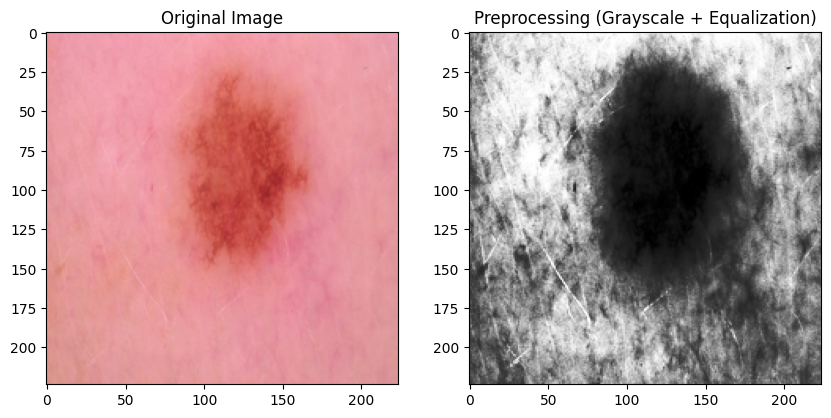

In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage import color, exposure

# load image
image = cv2.imread('Skin.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# preprocessing
gray = color.rgb2gray(image)
equalized = exposure.equalize_hist(gray)

# visualisasi
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Preprocessing (Grayscale + Equalization)")

plt.show()

BAGIAN 3

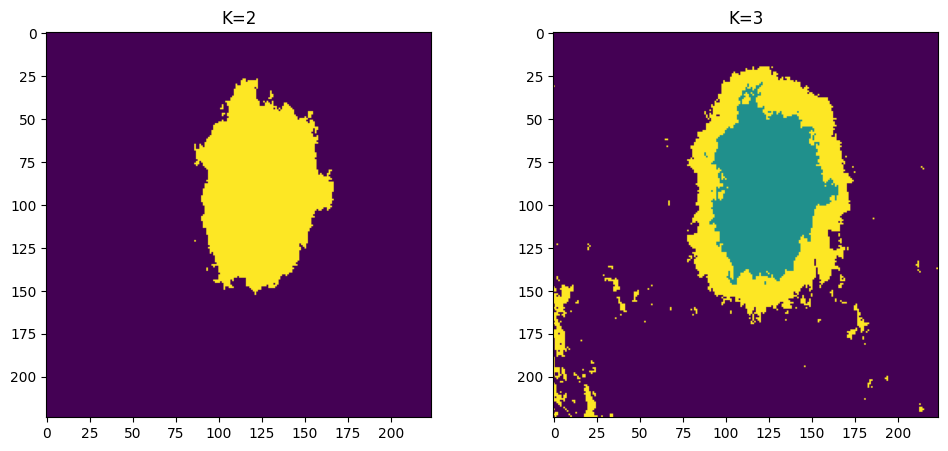

In [ ]:
import numpy as np
from sklearn.cluster import KMeans

# reshape image
pixels = image.reshape((-1,3))

# k = 2
kmeans2 = KMeans(n_clusters=2)
labels2 = kmeans2.fit_predict(pixels)

segmented2 = labels2.reshape(image.shape[:2])

# k = 3
kmeans3 = KMeans(n_clusters=3)
labels3 = kmeans3.fit_predict(pixels)

segmented3 = labels3.reshape(image.shape[:2])

# tampilkan
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(segmented2, cmap='viridis')
plt.title("K=2")

plt.subplot(1,2,2)
plt.imshow(segmented3, cmap='viridis')
plt.title("K=3")
plt.show()

BAGIAN 4- ELBOW METHOD

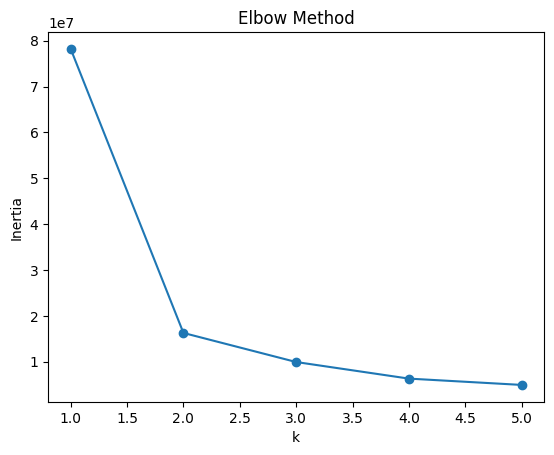

In [ ]:
inertia = []
k_range = range(1,6)

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pixels)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

BAGIAN 5

In [ ]:
def pilih_lesi(segmented, image):
    clusters = np.unique(segmented)
    mean_intensity = []

    for c in clusters:
        mask = segmented == c
        mean = np.mean(image[mask])
        mean_intensity.append(mean)

    # lesi biasanya lebih gelap
    lesion_cluster = clusters[np.argmin(mean_intensity)]

    return segmented == lesion_cluster

BAGIAN 7

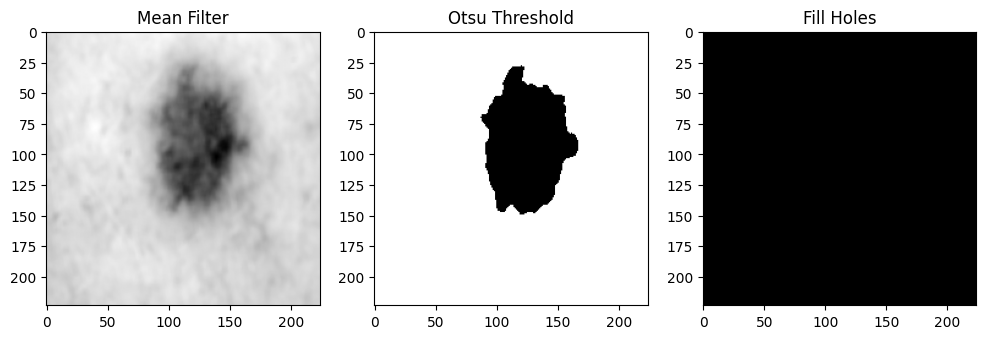

In [ ]:
from scipy.ndimage import uniform_filter
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_fill_holes
# mean filtering
smooth = uniform_filter(gray, size=5)

# threshold otsu
thresh = threshold_otsu(smooth)
binary = smooth > thresh

# filling holes
filled = binary_fill_holes(binary)

# tampilkan
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(smooth, cmap='gray')
plt.title("Mean Filter")

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Otsu Threshold")

plt.subplot(1,3,3)
plt.imshow(filled, cmap='gray')
plt.title("Fill Holes")

plt.show()

BAGIAN 9

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# flatten
X = pixels # X represents the pixel data
y = labels3 # Assigning labels3 from KMeans for classification. You can choose labels2 or define a different labeling strategy.

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# prediksi
y_pred = model.predict(X_test)

# akurasi
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9994021125357072
